# 📊 02 — Análise Exploratória de Dados (EDA)
**Nautical Store — Dataset 2023/2024**


## 1. Setup & Conexão

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Estilo global
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'DejaVu Sans',
})
PALETTE = ['#2563EB', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6', '#EC4899']
sns.set_palette(PALETTE)

# Conexão
DB_PATH = Path('/home/vinic/Documentos/Projetos/LH_Nautical/datasets/nautical.db')
assert DB_PATH.exists(), f"Banco não encontrado: {DB_PATH.resolve()}"
conn = sqlite3.connect(DB_PATH)
print(f"✅ Conectado a {DB_PATH.resolve()}")

FIG_PATH = '/home/vinic/Documentos/Projetos/LH_Nautical/figures/not02/'

# Tabelas disponíveis
tabelas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("\nTabelas:", tabelas['name'].tolist())


✅ Conectado a /home/vinic/Documentos/Projetos/LH_Nautical/datasets/nautical.db

Tabelas: ['vendas', 'produtos', 'clientes', 'custos']


### 1.1 Carregamento das tabelas

In [2]:
# Produtos
df_prod = pd.read_sql("SELECT * FROM produtos", conn)
# Rótulo legível para gráficos
CAT_LABEL = {'ELETRONICOS': 'Eletrônicos', 'PROPULSAO': 'Propulsão', 'ANCORAGEM': 'Ancoragem'}
df_prod['categoria'] = df_prod['category'].map(CAT_LABEL)

# Vendas
df_v = pd.read_sql("SELECT * FROM vendas", conn)
df_v['data']     = pd.to_datetime(df_v['sale_date'], format='mixed', dayfirst=False)  # SQLite devolve strings; no nautical.db todas já estão em ISO
df_v['ano']      = df_v['data'].dt.year
df_v['mes']      = df_v['data'].dt.month
df_v['mes_nome'] = df_v['data'].dt.strftime('%b')

# Clientes
df_cli = pd.read_sql("SELECT * FROM clientes", conn)

# Custos de importação
df_custos = pd.read_sql("SELECT * FROM custos", conn)
df_custos['data'] = pd.to_datetime(df_custos['start_date'])
# category no nautical.db: 'eletrônicos', 'propulsão', 'ancoragem'
df_custos['categoria'] = df_custos['category'].str.title()

print(f"Produtos  : {len(df_prod):>5} registros | colunas: {list(df_prod.columns)}")
print(f"Vendas    : {len(df_v):>5} registros  ({df_v['ano'].min()}–{df_v['ano'].max()})")
print(f"Clientes  : {len(df_cli):>5} registros | colunas: {list(df_cli.columns)}")
print(f"Custos    : {len(df_custos):>5} registros")
print(f"\nPeríodo de vendas: {df_v['data'].min().date()} → {df_v['data'].max().date()}")


Produtos  :   157 registros | colunas: ['name', 'price', 'code', 'category', 'categoria']
Vendas    :  9895 registros  (2023–2024)
Clientes  :    49 registros | colunas: ['full_name', 'code', 'email', 'state', 'city']
Custos    :  1260 registros

Período de vendas: 2023-01-01 → 2024-12-31


---
## 2. Análise de Produtos

Explorando o catálogo: distribuição por categoria, faixas de preço e extremos.

### 2.1 Estatísticas descritivas

In [3]:
print("=== Produtos por categoria ===")
print(df_prod['categoria'].value_counts().to_string())
print()
print("=== Preço (BRL) — estatísticas ===")
print(df_prod['price'].describe().apply(lambda x: f"R$ {x:,.2f}").to_string())


=== Produtos por categoria ===
categoria
Propulsão      53
Ancoragem      53
Eletrônicos    51

=== Preço (BRL) — estatísticas ===
count        R$ 157.00
mean      R$ 35,194.62
std       R$ 42,183.18
min          R$ 309.54
25%        R$ 3,769.93
50%       R$ 13,704.10
75%       R$ 51,634.04
max      R$ 148,198.23


### 2.2 Gráfico 1 — Distribuição por categoria

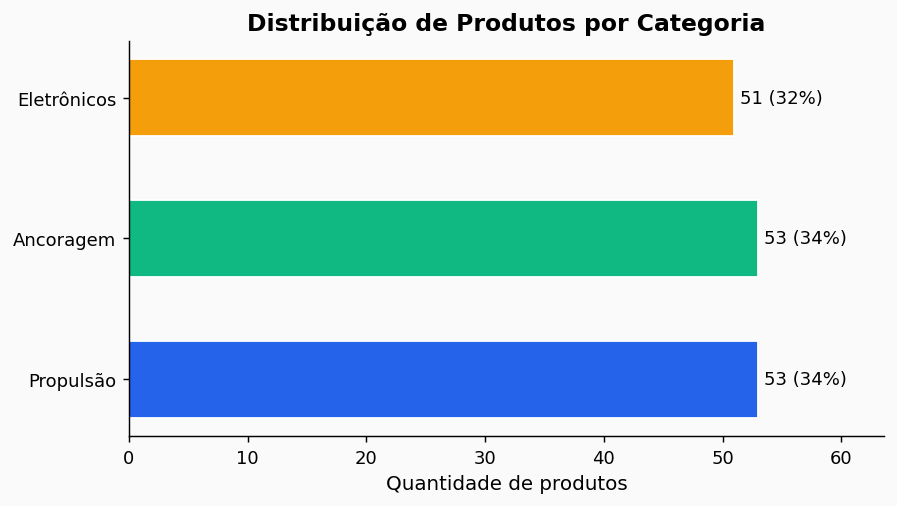

In [4]:
contagem = df_prod['categoria'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(contagem.index, contagem.values,
               color=PALETTE[:len(contagem)], edgecolor='white', height=0.55)

for bar, val in zip(bars, contagem.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df_prod)*100:.0f}%)',
            va='center', fontsize=10)

ax.set_xlabel('Quantidade de produtos')
ax.set_title('Distribuição de Produtos por Categoria')
ax.set_xlim(0, contagem.max() * 1.2)
plt.tight_layout()
plt.savefig(FIG_PATH +'g1_produtos_categoria.png', bbox_inches='tight')
plt.show()


### 2.3 Gráfico 2 — Histograma de preços por categoria

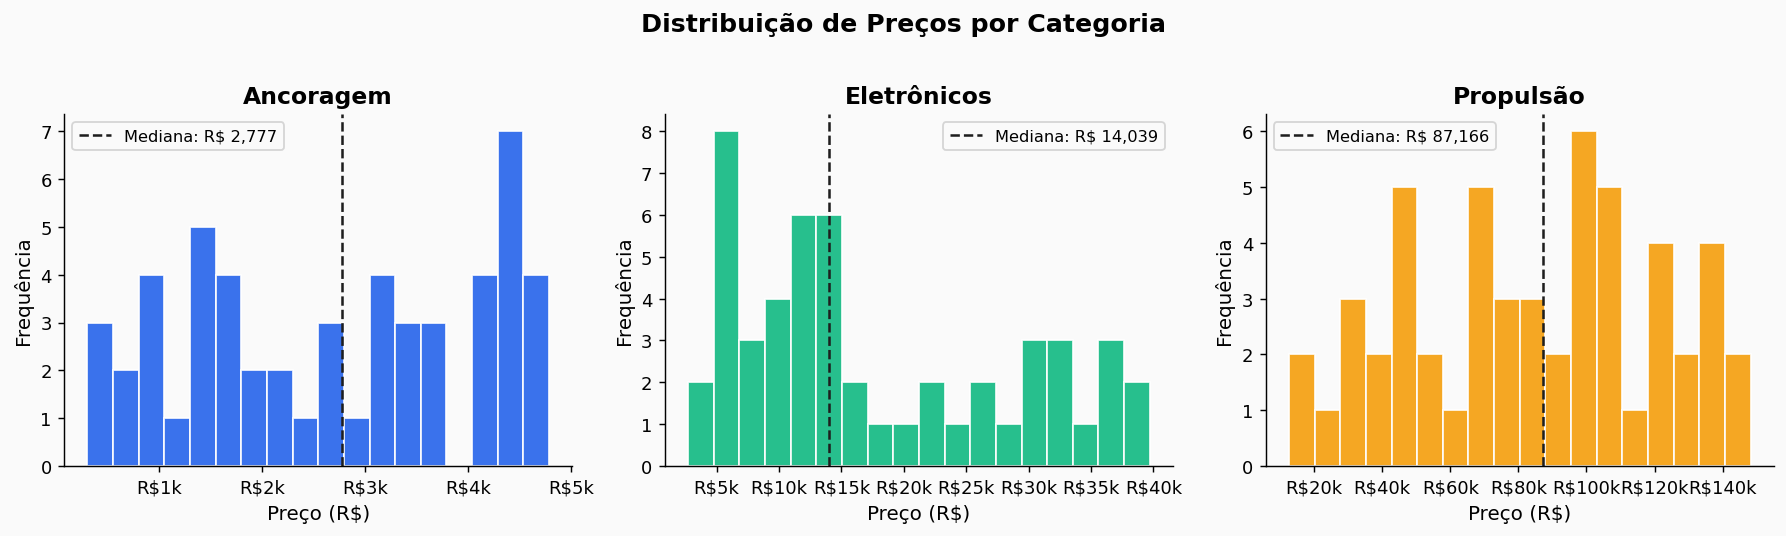

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
cats = sorted([c for c in df_prod['categoria'].unique() if isinstance(c, str)])

for ax, cat, color in zip(axes, cats, PALETTE):
    sub = df_prod[df_prod['categoria'] == cat]['price']
    ax.hist(sub, bins=18, color=color, edgecolor='white', alpha=0.9)
    ax.axvline(sub.median(), color='#1e1e1e', linestyle='--', linewidth=1.4,
               label=f'Mediana: R$ {sub.median():,.0f}')
    ax.set_title(f'{cat}')
    ax.set_xlabel('Preço (R$)')
    ax.set_ylabel('Frequência')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
    ax.legend(fontsize=9)

fig.suptitle('Distribuição de Preços por Categoria', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'g2_histograma_precos.png', bbox_inches='tight')
plt.show()


### 2.4 Top 5 — Produtos mais e menos caros

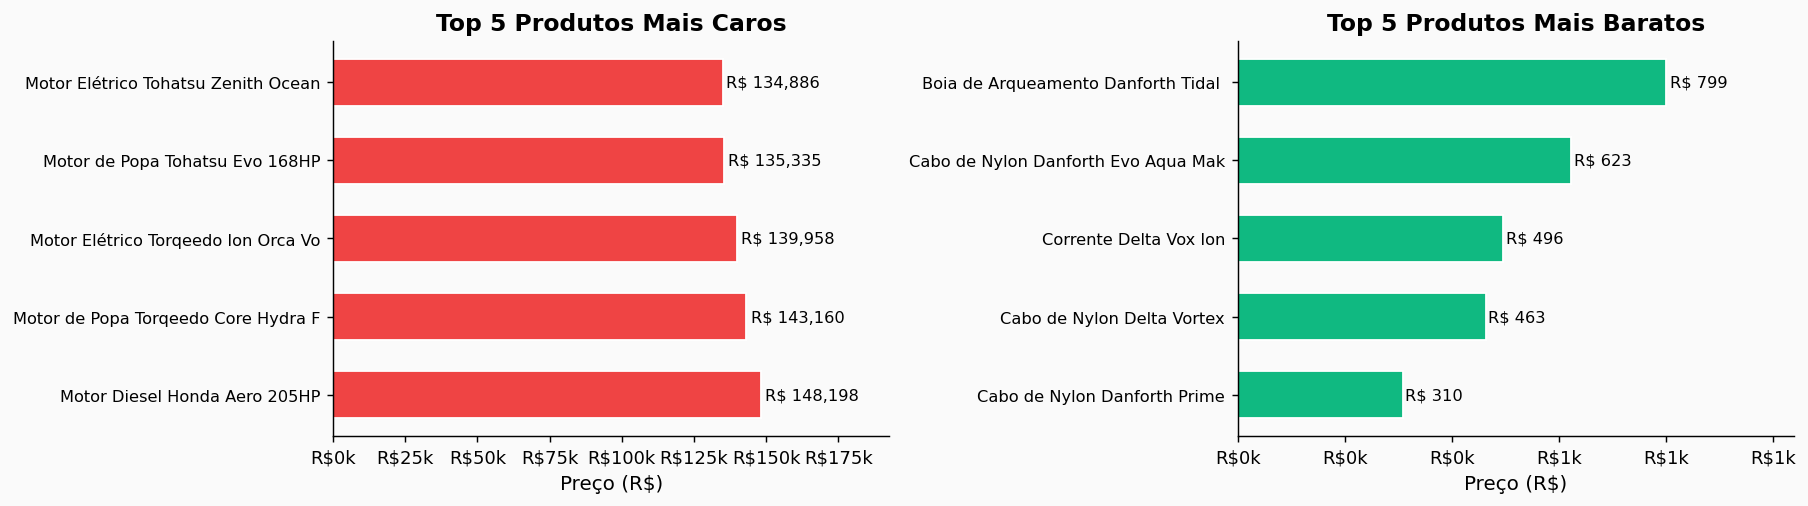

In [6]:
top5_caro    = df_prod.nlargest(5, 'price')[['name','categoria','price']]
top5_barato  = df_prod.nsmallest(5, 'price')[['name','categoria','price']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

def _hbar(ax, df, title, color):
    names = df['name'].str[:35]
    vals  = df['price']
    ax.barh(range(len(vals)), vals[::-1] if False else vals, color=color, edgecolor='white', height=0.6)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(names, fontsize=9)
    for i, v in enumerate(vals):
        ax.text(v * 1.01, i, f'R$ {v:,.0f}', va='center', fontsize=9)
    ax.set_xlabel('Preço (R$)')
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
    ax.set_xlim(0, vals.max() * 1.3)

_hbar(ax1, top5_caro,   'Top 5 Produtos Mais Caros',   PALETTE[3])
_hbar(ax2, top5_barato, 'Top 5 Produtos Mais Baratos', PALETTE[1])
plt.tight_layout()
plt.savefig(FIG_PATH + 'g2b_top5_precos.png', bbox_inches='tight')
plt.show()


---
## 3. Análise de Vendas

Comparativo 2023 vs 2024, sazonalidade mensal e distribuição de quantidade por pedido.

### 3.1 Estatísticas gerais de vendas

In [7]:
print("=== Vendas por ano ===")
print(df_v.groupby('ano').agg(
    n_vendas=('id','count'),
    receita_total=('total','sum'),
    ticket_medio=('total','mean')
).assign(
    receita_total=lambda d: d['receita_total'].map('R$ {:,.2f}'.format),
    ticket_medio =lambda d: d['ticket_medio'].map('R$ {:,.2f}'.format)
).to_string())


=== Vendas por ano ===
      n_vendas        receita_total   ticket_medio
ano                                               
2023      4991  R$ 1,288,827,294.55  R$ 258,230.27
2024      4904  R$ 1,321,452,216.15  R$ 269,464.16


### 3.2 Gráfico 3 — Total de vendas por mês (2023 vs 2024)

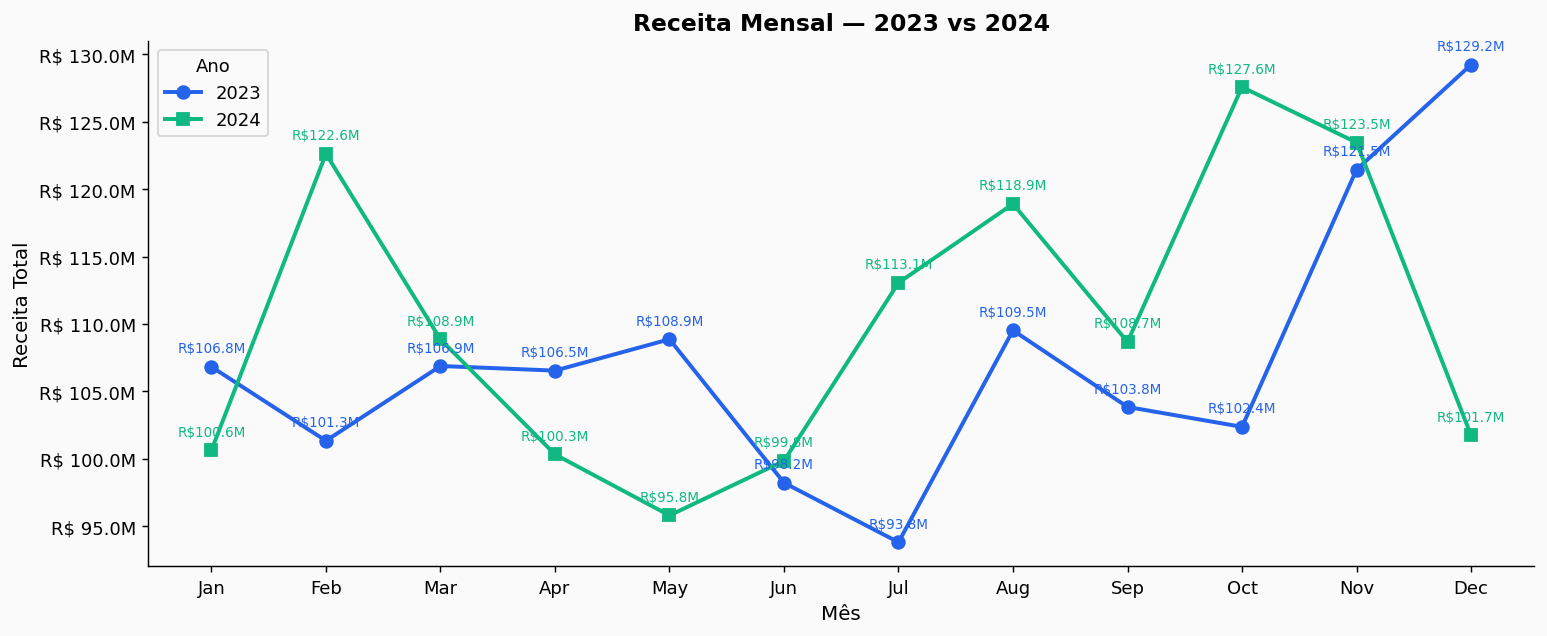

In [8]:
meses_ordem = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

mensal = (df_v.groupby(['ano','mes','mes_nome'])['total']
          .sum().reset_index()
          .sort_values(['ano','mes']))

fig, ax = plt.subplots(figsize=(12, 5))
for ano, color, marker in zip([2023, 2024], PALETTE[:2], ['o','s']):
    sub = mensal[mensal['ano'] == ano]
    ax.plot(sub['mes_nome'], sub['total']/1e6,
            marker=marker, linewidth=2.2, markersize=7,
            color=color, label=str(ano))
    for _, row in sub.iterrows():
        ax.annotate(f"R${row['total']/1e6:.1f}M",
                    (row['mes_nome'], row['total']/1e6),
                    textcoords='offset points', xytext=(0,8),
                    ha='center', fontsize=7.5, color=color)

ax.set_xticks(range(12))
ax.set_xticklabels(meses_ordem)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:.1f}M'))
ax.set_xlabel('Mês')
ax.set_ylabel('Receita Total')
ax.set_title('Receita Mensal — 2023 vs 2024')
ax.legend(title='Ano')
plt.tight_layout()
plt.savefig(FIG_PATH + 'g3_vendas_mensal.png', bbox_inches='tight')
plt.show()


### 3.3 Gráfico 4 — Sazonalidade (média dos dois anos)

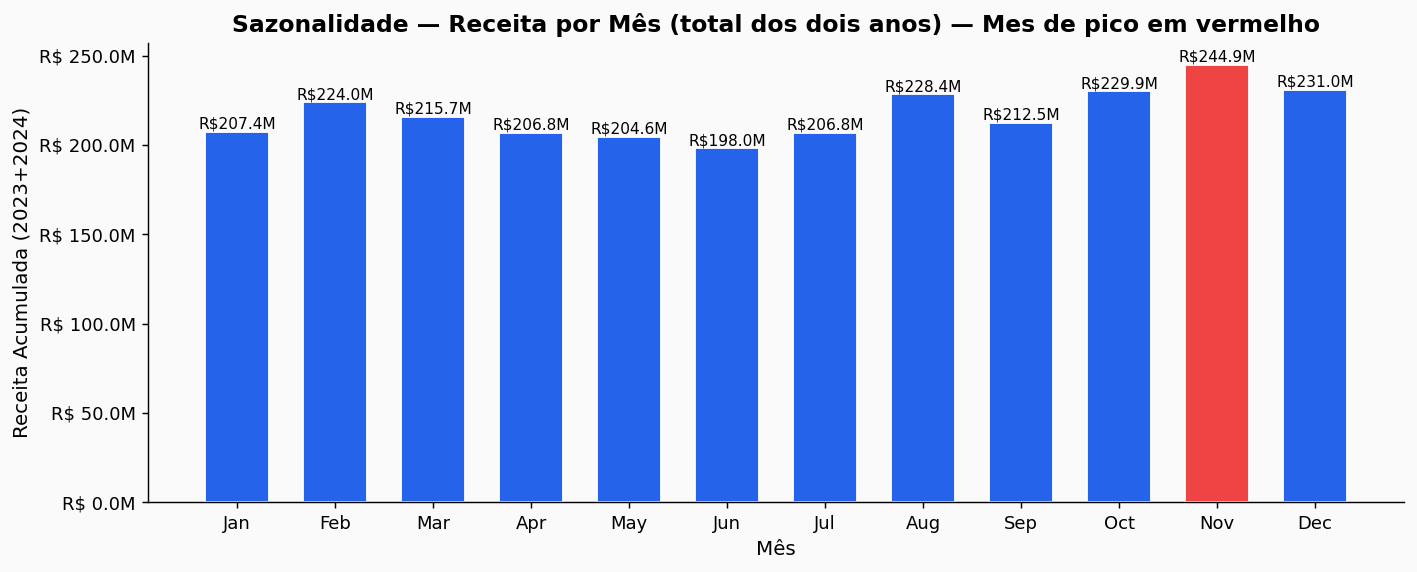

Mês de maior receita acumulada: Nov — R$ 244,915,250


In [9]:
sazon = (df_v.groupby('mes')['total']
         .sum()
         .reset_index()
         .sort_values('mes'))
sazon['mes_nome'] = pd.to_datetime(sazon['mes'], format='%m').dt.strftime('%b')

colors = [PALETTE[3] if v == sazon['total'].max() else PALETTE[0]
          for v in sazon['total']]

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(sazon['mes_nome'], sazon['total']/1e6,
              color=colors, edgecolor='white', width=0.65)

for bar, val in zip(bars, sazon['total']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'R${val/1e6:.1f}M', ha='center', va='bottom', fontsize=8.5)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:.1f}M'))
ax.set_xlabel('Mês')
ax.set_ylabel('Receita Acumulada (2023+2024)')
ax.set_title('Sazonalidade — Receita por Mês (total dos dois anos) — Mes de pico em vermelho')
plt.tight_layout()
plt.savefig(FIG_PATH + 'g4_sazonalidade.png', bbox_inches='tight')
plt.show()

pico = sazon.loc[sazon['total'].idxmax()]
print(f"Mês de maior receita acumulada: {pico['mes_nome']} — R$ {pico['total']:,.0f}")


### 3.4 Gráfico 5 — Distribuição de quantidade por venda (`qtd`)

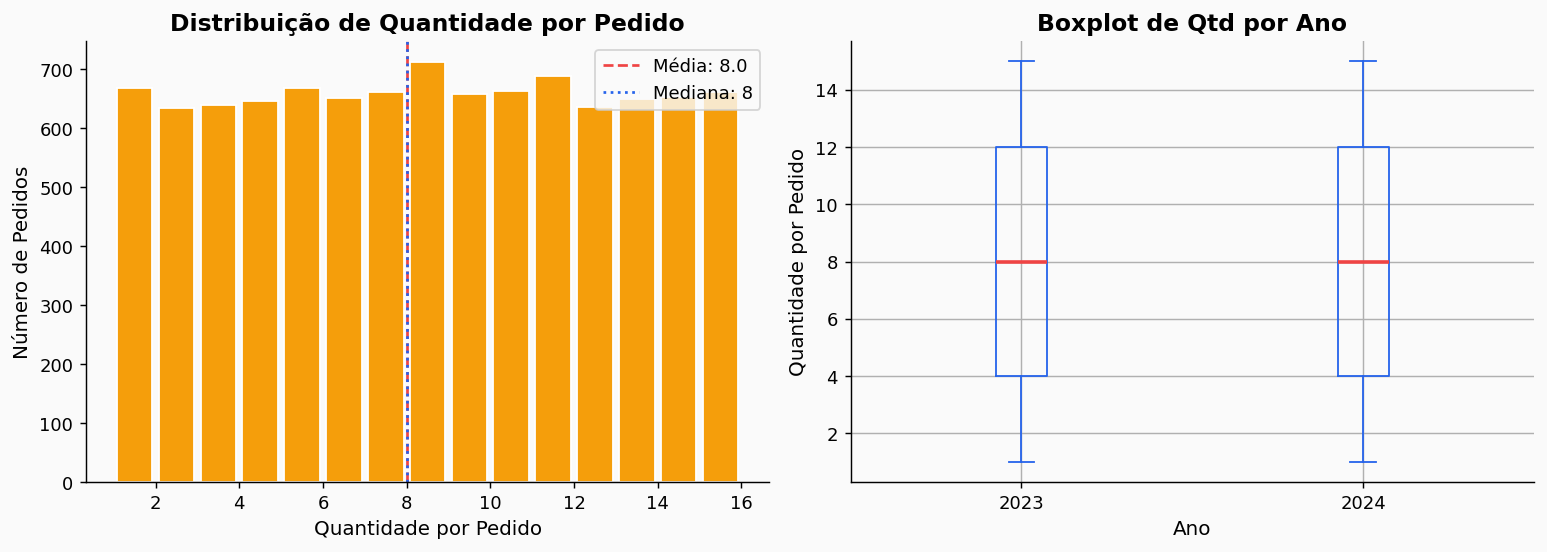

count    9895.000000
mean        8.015260
std         4.301723
min         1.000000
25%         4.000000
50%         8.000000
75%        12.000000
max        15.000000


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Histograma
ax1.hist(df_v['qtd'], bins=range(1, df_v['qtd'].max()+2),
         color=PALETTE[2], edgecolor='white', rwidth=0.85)
ax1.set_xlabel('Quantidade por Pedido')
ax1.set_ylabel('Número de Pedidos')
ax1.set_title('Distribuição de Quantidade por Pedido')
ax1.axvline(df_v['qtd'].mean(), color=PALETTE[3], linestyle='--',
            linewidth=1.5, label=f"Média: {df_v['qtd'].mean():.1f}")
ax1.axvline(df_v['qtd'].median(), color=PALETTE[0], linestyle=':',
            linewidth=1.5, label=f"Mediana: {df_v['qtd'].median():.0f}")
ax1.legend()

# Boxplot por ano
df_v.boxplot(column='qtd', by='ano', ax=ax2,
             boxprops=dict(color=PALETTE[0]),
             medianprops=dict(color=PALETTE[3], linewidth=2),
             whiskerprops=dict(color=PALETTE[0]),
             capprops=dict(color=PALETTE[0]),
             flierprops=dict(marker='o', color=PALETTE[2], alpha=0.3, markersize=4))
ax2.set_title('Boxplot de Qtd por Ano')
ax2.set_xlabel('Ano')
ax2.set_ylabel('Quantidade por Pedido')
plt.suptitle('')
plt.tight_layout()
plt.savefig(FIG_PATH + 'g5_distribuicao_qtd.png', bbox_inches='tight')
plt.show()

print(df_v['qtd'].describe().to_string())


---
## 4. Análise de Clientes

Distribuição geográfica por estado e frequência de compra.

### 4.1 Gráfico 6 — Distribuição geográfica por estado

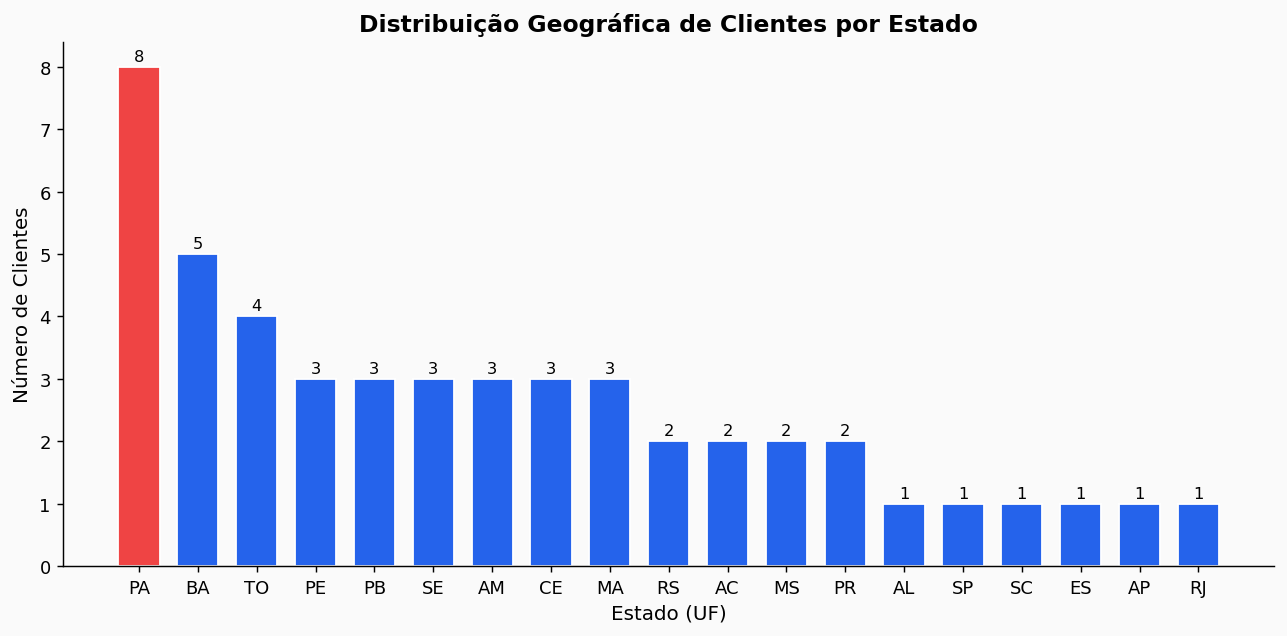

In [11]:
estados = df_cli['state'].value_counts().reset_index()
estados.columns = ['estado','clientes']

fig, ax = plt.subplots(figsize=(10, 5))
colors_map = [PALETTE[0] if v < estados['clientes'].max() else PALETTE[3]
              for v in estados['clientes']]
bars = ax.bar(estados['estado'], estados['clientes'],
              color=colors_map, edgecolor='white', width=0.7)

for bar, val in zip(bars, estados['clientes']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(val), ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Estado (UF)')
ax.set_ylabel('Número de Clientes')
ax.set_title('Distribuição Geográfica de Clientes por Estado')
plt.tight_layout()
plt.savefig(FIG_PATH + 'g6_clientes_estados.png', bbox_inches='tight')
plt.show()


### 4.2 Frequência de compra por cliente

In [12]:
freq = (df_v.groupby('id_client')
        .agg(n_pedidos=('id','count'), total_gasto=('total','sum'))
        .reset_index()
        .merge(df_cli[['code','full_name','state']], left_on='id_client', right_on='code', how='left')
        .sort_values('n_pedidos', ascending=False))

print("=== Top 10 clientes por número de pedidos ===")
print(freq.head(10)[['full_name','state','n_pedidos','total_gasto']]
      .assign(total_gasto=lambda d: d['total_gasto'].map('R$ {:,.2f}'.format))
      .to_string(index=False))

print(f"\nMédia de pedidos por cliente: {freq['n_pedidos'].mean():.1f}")
print(f"Mediana de pedidos por cliente: {freq['n_pedidos'].median():.0f}")


=== Top 10 clientes por número de pedidos ===
                             full_name state  n_pedidos      total_gasto
       Carla Lopes Alves Pacheco Rocha    TO        233 R$ 64,171,776.55
                     Márcia Figueiredo    PA        222 R$ 72,187,369.50
  Fernanda Azevedo Soares Nunes Vieira    PE        220 R$ 65,652,931.35
              Lucas Guedes Cunha Lopes    PB        218 R$ 66,788,855.35
              Diego Costa Guedes Cunha    RS        217 R$ 46,284,193.75
Femininos Antunes Lopes Ribeiro Amaral    ES        217 R$ 62,028,628.95
            Francisca Ribeiro Pinheiro    PA        215 R$ 62,791,038.15
                  Jéssica Farias Cunha    MA        213 R$ 53,647,337.30
              Luiz Borges Gomes Araújo    AM        213 R$ 58,073,741.00
       Letícia Torres Peixoto Oliveira    PE        213 R$ 53,739,847.75

Média de pedidos por cliente: 201.9
Mediana de pedidos por cliente: 202


---
## 5. Análise de Custos de Importação

Evolução do preço em USD ao longo do tempo, por categoria.

### 5.1 Gráfico 7 — Evolução média do preço USD por categoria

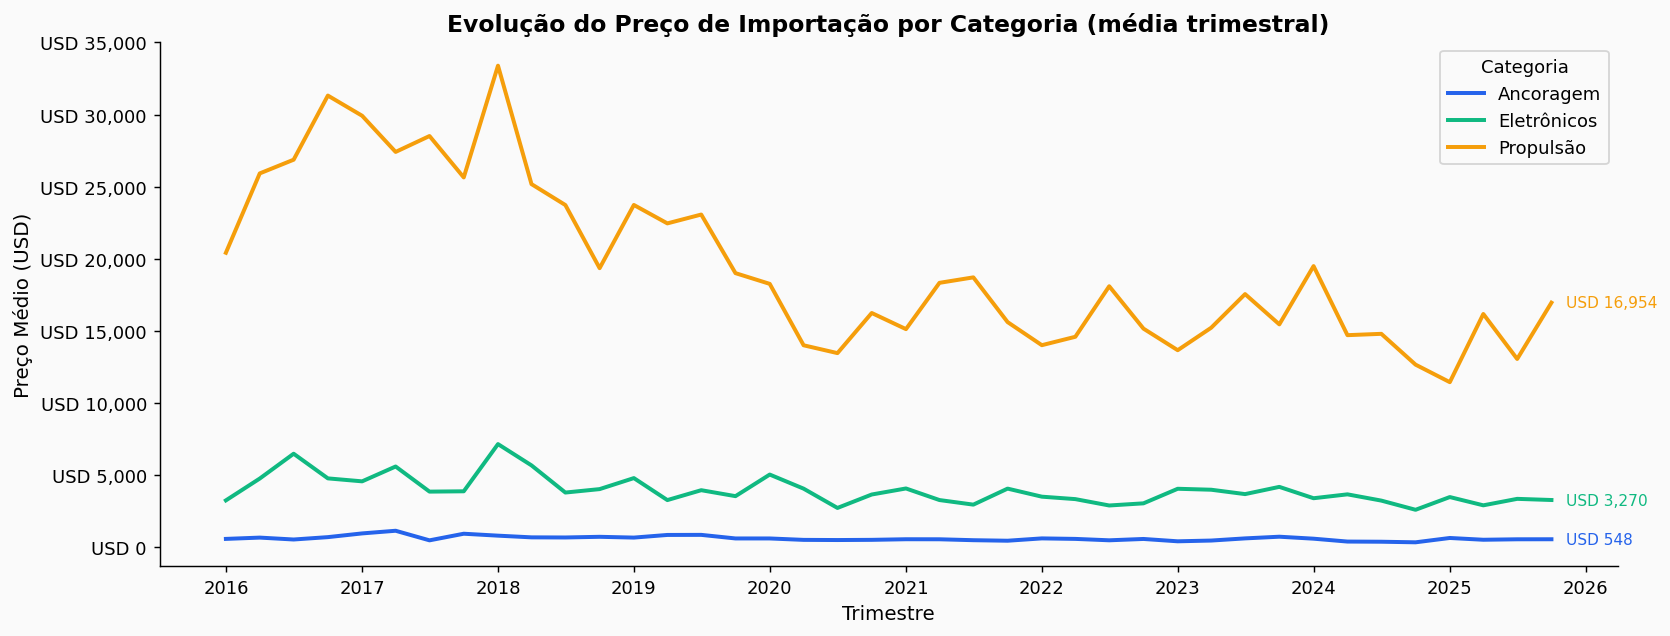

In [13]:
# Agrupa por categoria e mês
df_custos['ano_mes'] = df_custos['data'].dt.to_period('Q')
evolucao = (df_custos.groupby(['categoria','ano_mes'])['usd_price']
            .mean().reset_index())
evolucao['ano_mes_dt'] = evolucao['ano_mes'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))

for cat, color in zip(sorted(df_custos['categoria'].dropna().unique().tolist()), PALETTE):
    sub = evolucao[evolucao['categoria'] == cat].sort_values('ano_mes_dt')
    ax.plot(sub['ano_mes_dt'], sub['usd_price'],
            linewidth=2.2, label=cat.title(), color=color)
    # Marca último ponto
    last = sub.iloc[-1]
    ax.annotate(f"USD {last['usd_price']:,.0f}",
                (last['ano_mes_dt'], last['usd_price']),
                xytext=(8, 0), textcoords='offset points',
                fontsize=8.5, color=color, va='center')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'USD {x:,.0f}'))
ax.set_xlabel('Trimestre')
ax.set_ylabel('Preço Médio (USD)')
ax.set_title('Evolução do Preço de Importação por Categoria (média trimestral)')
ax.legend(title='Categoria')
plt.tight_layout()
plt.savefig(FIG_PATH + 'g7_custos_categoria.png', bbox_inches='tight')
plt.show()


### 5.2 Gráfico 8 — Variação de preço: mínimo, médio e máximo por categoria

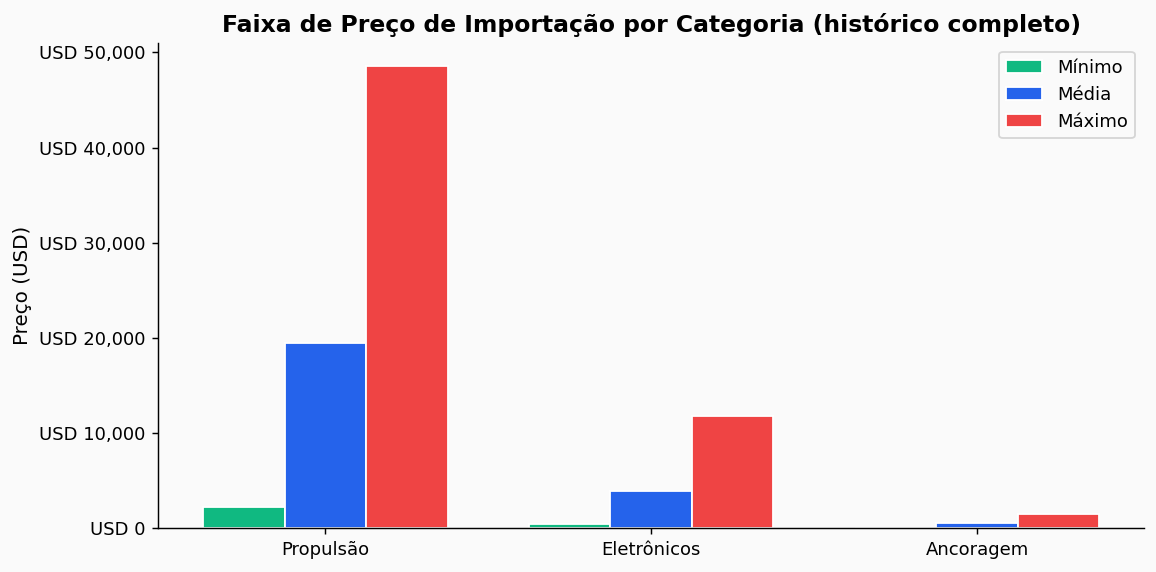

In [14]:
resumo = (df_custos.groupby('categoria')['usd_price']
          .agg(['min','mean','max'])
          .reset_index()
          .sort_values('mean', ascending=False))

x = np.arange(len(resumo))
w = 0.25

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w, resumo['min'],   width=w, label='Mínimo', color=PALETTE[1], edgecolor='white')
ax.bar(x,     resumo['mean'],  width=w, label='Média',  color=PALETTE[0], edgecolor='white')
ax.bar(x + w, resumo['max'],   width=w, label='Máximo', color=PALETTE[3], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(resumo['categoria'].str.title())
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'USD {x:,.0f}'))
ax.set_ylabel('Preço (USD)')
ax.set_title('Faixa de Preço de Importação por Categoria (histórico completo)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_PATH + 'g8_custos_faixa.png', bbox_inches='tight')
plt.show()


---
## 6. Conclusões

### Produtos
- O catálogo tem **3 categorias**: Eletrônicos, Propulsão e Ancoragem.
- **Propulsão** concentra os produtos mais caros (motores acima de R$ 100k), enquanto **Ancoragem** reúne os itens mais acessíveis.

### Vendas
- Há variação relevante de receita entre meses — identifique os **meses de pico** para ações de marketing sazonais.
- A distribuição de `qtd` por pedido é **assimétrica à direita**: a maioria dos pedidos tem poucos itens, mas alguns pedidos grandes puxam a média.

### Clientes
- Base concentrada no **Norte e Nordeste** (PA, BA, TO, CE…), coerente com o perfil náutico costeiro.
- Grande variação na frequência de compra — oportunidade para programas de **fidelização**.

### Custos de Importação
- Os preços em USD mostram **tendência de queda** no longo prazo em quase todas as categorias.
- **Propulsão** tem os maiores preços absolutos e maior variância, exigindo maior atenção ao câmbio.
